In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import fsspec, os
import scipy as sp
import PIL
from PIL import Image
import random
import os
import glob
import re

In [2]:
# Parameters
state = None
selected_data_type = None
RESERVED_SHOT = None
EPOCH_NUM = None
VALIDATION_SPLIT = None
ACTIVATION_FUNC = None
LOSS_FUNC = None
OPTIMIZER_FUNC = None
OUTLIER_CUTOFF = None
NUM_CONV2D_LAYERS = None
NUM_DENSE_LAYERS = None
CONV2D_NEURONS = None
CONV2D_SIZE = None
DENSE_LAYER_NEURONS = None
MAX_POOLING_SIZE = None

In [3]:
# Parameters
state = 2
selected_data_type = "ma2"
RESERVED_SHOT = 114458
EPOCH_NUM = 35
VALIDATION_SPLIT = 0.1
ACTIVATION_FUNC = "relu"
LOSS_FUNC = "mae"
OPTIMIZER_FUNC = "adam"
OUTLIER_CUTOFF = 92.0
NUM_CONV2D_LAYERS = 3
NUM_DENSE_LAYERS = 1
CONV2D_NEURONS = [16, 8, 64]
CONV2D_SIZE = ["(5, 5)", "(8, 8)", "(4, 4)"]
DENSE_LAYER_NEURONS = [32]
MAX_POOLING_SIZE = "(2, 2)"


In [4]:
# Manual override logic
manual = False  # Toggle this to True to use manual values, False to skip

if manual:
    state = 1  # state 1, 2, or 3
    selected_data_type = 'ma2'  # ma2 basically always
    if state == 1:
        RESERVED_SHOT = 119671  # for state 1
    elif state == 2:
        RESERVED_SHOT = 114458  # for state 2
    else:
        RESERVED_SHOT = 119671  # Default for state 3 (choosing one from RESERVED_SHOTS[3])
    EPOCH_NUM = 15  # 15
    VALIDATION_SPLIT = 0.2  # 0.2
    ACTIVATION_FUNC = 'relu'  # 'relu'
    LOSS_FUNC = 'mae'  # 'mae'
    OPTIMIZER_FUNC = 'adam'  # 'adam'
    OUTLIER_CUTOFF = 99  # 99
    NUM_CONV2D_LAYERS = 2  # 2 Conv2D layers
    NUM_DENSE_LAYERS = 1  # 1 dense layer
    CONV2D_NEURONS = [16, 16]  # Neurons per Conv2D layer
    CONV2D_SIZE = [(8, 8), (8, 8)]  # Kernel sizes for Conv2D layers
    DENSE_LAYER_NEURONS = [10]  # Neurons for dense layer
    MAX_POOLING_SIZE = (4, 4)  # Max pooling size

    # Update parameters dictionary for Papermill
    parameters = {
        'state': state,
        'selected_data_type': selected_data_type,
        'RESERVED_SHOT': RESERVED_SHOT,
        'EPOCH_NUM': EPOCH_NUM,
        'VALIDATION_SPLIT': VALIDATION_SPLIT,
        'ACTIVATION_FUNC': ACTIVATION_FUNC,
        'LOSS_FUNC': LOSS_FUNC,
        'OPTIMIZER_FUNC': OPTIMIZER_FUNC,
        'OUTLIER_CUTOFF': OUTLIER_CUTOFF,
        'NUM_CONV2D_LAYERS': NUM_CONV2D_LAYERS,
        'NUM_DENSE_LAYERS': NUM_DENSE_LAYERS,
        'CONV2D_NEURONS': CONV2D_NEURONS,
        'CONV2D_SIZE': CONV2D_SIZE,
        'DENSE_LAYER_NEURONS': DENSE_LAYER_NEURONS,
        'MAX_POOLING_SIZE': MAX_POOLING_SIZE
    }

In [5]:
# Define shot lists and file paths
#state = 1  # state 1 -> javier, state 2 -> william, state 3 -> combined
if state == 1:
    shot_list = [119591, 119599, 119601, 119646, 119648, 119653, 119654, 119658, 119659,
             119661, 119662, 119663, 119665, 119666, 119667, 119669, 119670, 119671,
             119673, 119675, 119748, 119750, 119751, 119752, 119754, 119755, 119756,
             119757, 119760, 119761, 119762, 119763, 119764, 119766, 119767, 119768, 119769]
    file_path = '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/Input Data/Shots/' 
    file_path_hbt = '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/python_hbteplib_data/'
elif state == 2:
    shot_list = [114407,114408,114411,114412,114413,114415,114416,114417,114418,114419,114420,114422,114424,114425,114428,114429,114431,114432,114433,
                 114434,114435,114436,114438,114439,114441,114443,114444,114445,114448,114450,114451,114453,114454,114455,114456,114457,114458,114460,
                 114462,114464,114467,114468,114472,114473]
    file_path = '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/Input Data/Old Shots/' 
    file_path_hbt = '//Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/oldshot_python_hbteplib_data/' 
elif state == 3:
    shot_list = [119591, 119599, 119601, 119646, 119648, 119653, 119654, 119658, 119659,
             119661, 119662, 119663, 119665, 119666, 119667, 119669, 119670, 119671,
             119673, 119675, 119748, 119750, 119751, 119752, 119754, 119755, 119756,
             119757, 119760, 119761, 119762, 119763, 119764, 119766, 119767, 119768, 119769,
             114407,114408,114411,114412,114413,114415,114416,114417,114418,114419,114420,114422,114424,114425,114428,114429,114431,114432,114433,
             114434,114435,114436,114438,114439,114441,114443,114444,114445,114448,114450,114451,114453,114454,114455,114456,114457,114458,114460,
             114462,114464,114467,114468,114472,114473]
    # For shots >= 119000, use Javier's paths
    # For shots < 119000, use William's paths
def get_paths_for_shot(shot_num):
        if shot_num >= 119000:
            return ('/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/Input Data/Shots/',
                   '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/python_hbteplib_data/')
        else:
            return ('/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/Input Data/Old Shots/',
                   '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/oldshot_python_hbteplib_data/')
 
#selected_data_type = 'ma4'  # Options: 'ma1', 'ma2', 'ma3', 'ma4', 'mp1', 'mp2', 'mp3', 'mp4'
# Notebook type definition
notebook_type = 'untrimmed'  # Set to 'trimmed' or 'untrimmed' based on the notebook
TARGET_FRAME_COUNT = 800
CAMERA_DEPTH = 65535.0 # 2^16
#RESERVED_SHOT = 119671  # Set to a specific shot number or None for random selection

In [6]:
# Helper functions for data processing
def determine_frame_ratio(num_frames, target_frames=TARGET_FRAME_COUNT):
    """
    Determines the frame ratio needed to downsample the data to target_frames.
    Returns the ratio and the actual number of frames after downsampling.
    """
    ratio = max(1, num_frames // target_frames)
    actual_frames = num_frames // ratio
    return ratio, actual_frames

def process_shot_data(folder_path, target_frame_count, max_pixel_value, state, shot_num=None):
    """
    Process a single shot's data with automatic frame rate handling.
    Returns: 2D data (32x32), cut 2D data (32x32), and flat data for the shot
    """
    tiff_files = sorted(glob.glob(os.path.join(folder_path, "*.tiff")))
    num_frames = len(tiff_files)
    
    if num_frames == 0:
        raise ValueError(f"No TIFF files found in {folder_path}")
    
    frame_ratio, actual_frames = determine_frame_ratio(num_frames, target_frame_count)
    
    # Initialize shot lists
    flat_shot = []
    shot_2d = []
    cut_shot = []
    
    # Process TIFF files with dynamic frame ratio
    for j, tiff_file in enumerate(tiff_files):
        if j % frame_ratio == 0 and len(shot_2d) < target_frame_count:
            try:
                im = Image.open(tiff_file)
                im = np.array(im, dtype=np.float32)
                im = im / max_pixel_value
                
                # Automatically crop the center 32x32 region of the image
                h, w = im.shape
                if h < 32 or w < 32:
                    raise ValueError(f"Image too small to crop to 32x32: got {h}x{w}")

                start_h = (h - 32) // 2
                start_w = (w - 32) // 2
                cropped_im = im[start_h:start_h + 32, start_w:start_w + 32]

                
                flat_im = cropped_im.reshape(-1)  # Flatten the cropped image (32*32 = 1024)
                cut_2d = cropped_im  # cut_2d is the same as cropped_im (32x32)
                
                shot_2d.append(cropped_im)  # Store cropped image (32x32)
                flat_shot.append(flat_im)
                cut_shot.append(cut_2d)
                
            except Exception as e:
                print(f"Error loading {tiff_file}: {e}")
                continue
    
    return np.array(shot_2d), np.array(cut_shot), np.array(flat_shot)
    
def process_all_shots(shot_list, base_path, max_pixel_value, target_frame_count, state):
    """
    Process multiple shots with automatic frame rate handling
    """
    training_data_2D = []
    cut_training_data_2D = []
    flat_training_data = []
    valid_shots = []
    
    for shot in shot_list:
        if shot == RESERVED_SHOT:
            continue
        if state == 3:
            file_path, _ = get_paths_for_shot(shot)
            folder_path = os.path.join(file_path, str(shot), 'CAM-26731/tiff/')
        else:
            folder_path = os.path.join(base_path, str(shot), 'CAM-26731/tiff/')
        
        try:
            shot_2d, cut_2d, flat_data = process_shot_data(folder_path, target_frame_count, max_pixel_value, state, shot_num=shot)
            
            if len(shot_2d) == target_frame_count:
                training_data_2D.append(shot_2d)
                cut_training_data_2D.append(cut_2d)
                flat_training_data.append(flat_data)
                valid_shots.append(shot)
            else:
                print(f"Shot {shot} produced {len(shot_2d)} frames, expected {target_frame_count}. Skipping.")
                
        except Exception as e:
            print(f"Error processing shot {shot}: {e}")
            continue
    
    return (np.array(training_data_2D), 
            np.array(cut_training_data_2D), 
            np.array(flat_training_data), valid_shots)

In [7]:
# Load and format HBT data
def format_hbt_data(data, mode_num):
    # Determine frame ratio
    original_length = data[0][0].shape[0] # 5000
    target_length = TARGET_FRAME_COUNT
    frame_ratio = original_length // target_length  # generally 5 (5000/TARGET_FRAME_COUNT)
    
    data = np.asarray(data, dtype=float)
    data = np.reshape(data[:,mode_num-1,:], (len(data), original_length, 1))
    data = data[:,::frame_ratio,:]
    data = data[:,:target_length,:]
    return data

# Load HBT data
hbt_ma_data = []
hbt_mp_data = []
hbt_time_data = []
valid_shots_hbt = []
for i in range(len(shot_list)):
    shot = shot_list[i]
    if state == 3:
        _, file_path_hbt = get_paths_for_shot(shot)
    else:
        file_path_hbt = file_path_hbt
        
    try:
        ma_list = []
        mp_list = []
        for j in range(1,5):
            ma_data = np.load(os.path.join(file_path_hbt, f'{shot}m{j}Amp.npy'))
            mp_data = np.load(os.path.join(file_path_hbt, f'{shot}m{j}Phase.npy'))
            ma_list.append(ma_data)
            mp_list.append(mp_data)
        
        hbt_ma_data.append(ma_list)
        hbt_mp_data.append(mp_list)
        time_data = np.load(os.path.join(file_path_hbt, f'{shot}time.npy'))
        hbt_time_data.append(time_data)
        valid_shots_hbt.append(shot)
    except Exception as e:
        print(f"Error loading HBT data for shot {shot}: {e}")
        continue

# Format HBT data
hbt_ma1_data = format_hbt_data(hbt_ma_data, 1)
hbt_ma2_data = format_hbt_data(hbt_ma_data, 2)
hbt_ma3_data = format_hbt_data(hbt_ma_data, 3)
hbt_ma4_data = format_hbt_data(hbt_ma_data, 4)

hbt_mp1_data = format_hbt_data(hbt_mp_data, 1)
hbt_mp2_data = format_hbt_data(hbt_mp_data, 2)
hbt_mp3_data = format_hbt_data(hbt_mp_data, 3)
hbt_mp4_data = format_hbt_data(hbt_mp_data, 4)

# Format time data
hbt_time_data = np.asarray(hbt_time_data, dtype=float)
hbt_time_data = np.reshape(hbt_time_data, (len(hbt_time_data), hbt_ma_data[0][0].shape[0]))
original_length = hbt_time_data.shape[1]
frame_ratio = original_length // TARGET_FRAME_COUNT
hbt_time_data = hbt_time_data[:,::frame_ratio]
hbt_time_data = hbt_time_data[:,:TARGET_FRAME_COUNT]

# Assign hbt_dataType based on selected_data_type
data_type_mapping = {
    'ma1': hbt_ma1_data,
    'ma2': hbt_ma2_data,
    'ma3': hbt_ma3_data,
    'ma4': hbt_ma4_data,
    'mp1': hbt_mp1_data,
    'mp2': hbt_mp2_data,
    'mp3': hbt_mp3_data,
    'mp4': hbt_mp4_data
}
if selected_data_type not in data_type_mapping:
    raise ValueError(f"Invalid selected_data_type: {selected_data_type}. Choose from {list(data_type_mapping.keys())}")
hbt_dataType = data_type_mapping[selected_data_type]

print("HBT data shapes:")
print(f"Mode amplitude 1: {hbt_ma1_data.shape}")
print(f"Mode phase 1: {hbt_mp1_data.shape}")
print(f"Time data: {hbt_time_data.shape}")


# Process shot list
if state == 3:
    training_data_2D, cut_training_data_2D, flat_training_data, valid_shots = process_all_shots(shot_list, None, CAMERA_DEPTH, TARGET_FRAME_COUNT, 3)
else:
    training_data_2D, cut_training_data_2D, flat_training_data, valid_shots = process_all_shots(shot_list, file_path, CAMERA_DEPTH, TARGET_FRAME_COUNT, state)   
print(f"training_data_2D shape: {training_data_2D.shape}")
print(f"cut_training_data_2D shape: {cut_training_data_2D.shape}")

# Process RESERVED_SHOT separately for testing
reserved_shot_data_2d = None
reserved_shot_cut_2d = None
reserved_shot_flat = None
if RESERVED_SHOT is not None:
    if state == 3:
        file_path, _ = get_paths_for_shot(RESERVED_SHOT)
        folder_path = os.path.join(file_path, str(RESERVED_SHOT), 'CAM-26731/tiff/')
    else:
        folder_path = os.path.join(file_path, str(RESERVED_SHOT), 'CAM-26731/tiff/')
    
    try:
        shot_2d, cut_2d, flat_data = process_shot_data(folder_path, TARGET_FRAME_COUNT, CAMERA_DEPTH, state, shot_num=RESERVED_SHOT)
        if len(shot_2d) == TARGET_FRAME_COUNT:
            reserved_shot_data_2d = shot_2d
            reserved_shot_cut_2d = cut_2d
            reserved_shot_flat = flat_data
            print(f"Successfully processed RESERVED_SHOT {RESERVED_SHOT} with {len(shot_2d)} frames")
        else:
            print(f"RESERVED_SHOT {RESERVED_SHOT} produced {len(shot_2d)} frames, expected {TARGET_FRAME_COUNT}. Falling back to random shot.")
            RESERVED_SHOT = random.choice(valid_shots)
            folder_path = os.path.join(file_path, str(RESERVED_SHOT), 'CAM-26731/tiff/')
            shot_2d, cut_2d, flat_data = process_shot_data(folder_path, TARGET_FRAME_COUNT, CAMERA_DEPTH, state, shot_num=RESERVED_SHOT)
            reserved_shot_data_2d = shot_2d
            reserved_shot_cut_2d = cut_2d
            reserved_shot_flat = flat_data
    except Exception as e:
        print(f"Error processing RESERVED_SHOT {RESERVED_SHOT}: {e}. Falling back to random shot.")
        RESERVED_SHOT = random.choice(valid_shots)
        folder_path = os.path.join(file_path, str(RESERVED_SHOT), 'CAM-26731/tiff/')
        shot_2d, cut_2d, flat_data = process_shot_data(folder_path, TARGET_FRAME_COUNT, CAMERA_DEPTH, state, shot_num=RESERVED_SHOT)
        reserved_shot_data_2d = shot_2d
        reserved_shot_cut_2d = cut_2d
        reserved_shot_flat = flat_data

# Set RESERVED_SHOT if None
if RESERVED_SHOT is None:
    RESERVED_SHOT = random.choice(valid_shots)
    print(f"Randomly selected reserved shot: {RESERVED_SHOT}")
    if state == 3:
        file_path, _ = get_paths_for_shot(RESERVED_SHOT)
        folder_path = os.path.join(file_path, str(RESERVED_SHOT), 'CAM-26731/tiff/')
    else:
        folder_path = os.path.join(file_path, str(RESERVED_SHOT), 'CAM-26731/tiff/')
    shot_2d, cut_2d, flat_data = process_shot_data(folder_path, TARGET_FRAME_COUNT, CAMERA_DEPTH, state, shot_num=RESERVED_SHOT)
    reserved_shot_data_2d = shot_2d
    reserved_shot_cut_2d = cut_2d
    reserved_shot_flat = flat_data

HBT data shapes:
Mode amplitude 1: (44, 800, 1)
Mode phase 1: (44, 800, 1)
Time data: (44, 800)


training_data_2D shape: (43, 800, 32, 32)
cut_training_data_2D shape: (43, 800, 32, 32)


Successfully processed RESERVED_SHOT 114458 with 800 frames


Normalization factor (92.0 percentile): 3.66
Number of outliers (|value| > 10.99): 133
Saved normalization info to normalization_untrimmed_state_2.npz
Training shape: (34200, 32, 32, 1) Target shape: (34200,)
Testing shape: (200, 32, 32, 1) Testing label shape: (200,)


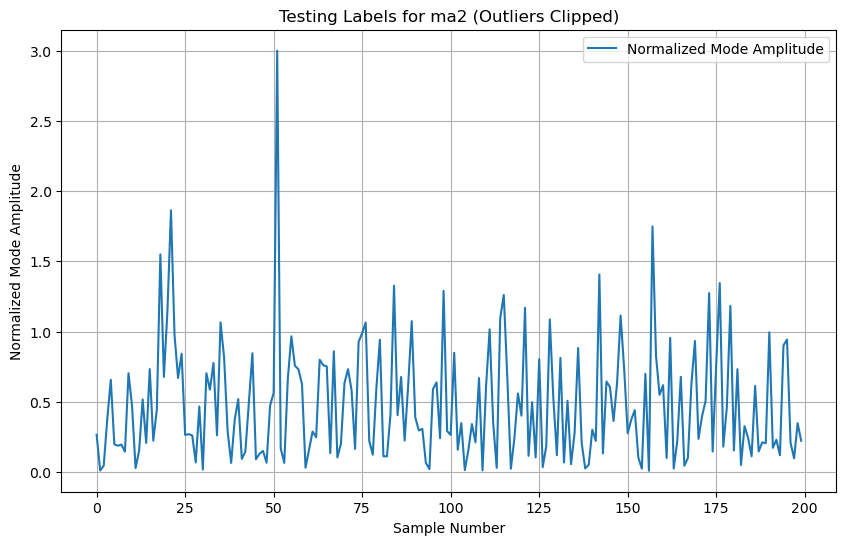

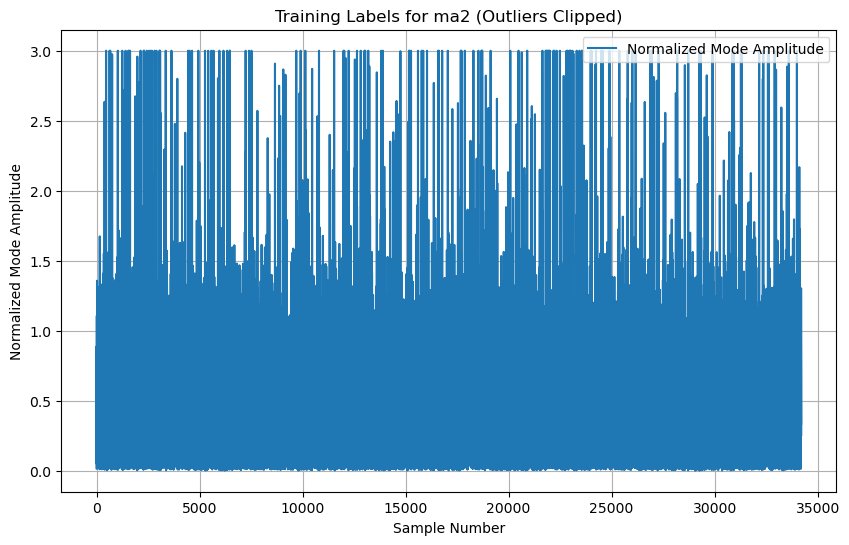

In [8]:
# Prepare data for HBT prediction model
target_data = hbt_dataType  # Using mode 2 amplitude as target
training_data = cut_training_data_2D

# Normalization factors
camera_norm = 1  # Camera data already normalized by max_pixel_value
# Compute ma_norm using 90th percentile to handle outliers
raw_target_vector = []
for i in range(len(valid_shots)):
    shot = valid_shots[i]
    if shot == RESERVED_SHOT:
        continue
    for j in range(len(target_data[i])):
        raw_target_vector.append(target_data[i][j])

raw_target_vector = np.asarray(raw_target_vector, dtype=np.float32)[:, 0]
percentile_cutoff = np.percentile(np.abs(raw_target_vector), OUTLIER_CUTOFF) #99%
ma_norm = percentile_cutoff if percentile_cutoff > 0 else 1.0  # Use 99th percentile for normalization
outlier_threshold = 3 * ma_norm  # Define outliers as values > 3 * normalization factor
outliers = np.abs(raw_target_vector) > outlier_threshold
print(f"Normalization factor ({OUTLIER_CUTOFF} percentile): {ma_norm:.2f}")
print(f"Number of outliers (|value| > {outlier_threshold:.2f}): {np.sum(outliers)}")

# Clip outliers for normalization
raw_target_vector = np.clip(raw_target_vector, -outlier_threshold, outlier_threshold)

# Reshape the training data and labels, excluding RESERVED_SHOT
target_vector = []
training_vector = []
for i in range(len(valid_shots)):
    shot = valid_shots[i]
    if shot == RESERVED_SHOT:
        continue
    for j in range(len(target_data[i])):
        target_vector.append(target_data[i][j])
        training_vector.append(training_data[i][j])

# Shuffle the data
random.seed(123)
zip_list = list(zip(target_vector, training_vector))
random.shuffle(zip_list)
target_vector, training_vector = zip(*zip_list)

# Convert to numpy arrays and normalize with clipping
target_vector = np.asarray(target_vector, dtype=np.float32)[:, 0]
target_vector = np.clip(target_vector, -outlier_threshold, outlier_threshold) / ma_norm
training_vector = np.asarray(training_vector, dtype=np.float32).reshape(-1, 32, 32, 1)

# Split into training and testing sets
test_size = 200
testing_inputs = training_vector[-test_size:]
testing_labels = target_vector[-test_size:]
training_vector = training_vector[:-test_size]
target_vector = target_vector[:-test_size]

# Save normalization info to a per-run file
normalization_filename = f"normalization_{notebook_type}_state_{state}.npz"
np.savez(normalization_filename,
         ma_norm=ma_norm,
         outlier_threshold=outlier_threshold,
         selected_data_type=selected_data_type)
print(f"Saved normalization info to {normalization_filename}")

print('Training shape:', training_vector.shape, 'Target shape:', target_vector.shape)
print('Testing shape:', testing_inputs.shape, 'Testing label shape:', testing_labels.shape)

# Plot testing labels
plt.figure(figsize=(10, 6))
plt.plot(testing_labels, label='Normalized Mode Amplitude')
plt.xlabel('Sample Number')
plt.ylabel('Normalized Mode Amplitude')
plt.title(f'Testing Labels for {selected_data_type} (Outliers Clipped)')
plt.grid(True)
plt.legend()
plt.show()

# Plot training labels
plt.figure(figsize=(10, 6))
plt.plot(target_vector, label='Normalized Mode Amplitude')
plt.xlabel('Sample Number')
plt.ylabel('Normalized Mode Amplitude')
plt.title(f'Training Labels for {selected_data_type} (Outliers Clipped)')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
import ast

# Define model architecture
num_conv2d_layers = NUM_CONV2D_LAYERS #2
num_dense_layers = NUM_DENSE_LAYERS #1

conv2d_neurons = CONV2D_NEURONS #[16, 16]
conv2d_size = CONV2D_SIZE #[(8, 8), (8, 8)]
dense_layer_neurons = DENSE_LAYER_NEURONS #[10]
max_pooling_size = MAX_POOLING_SIZE #(4, 4)
activation_func = ACTIVATION_FUNC # 'relu'
loss_func = LOSS_FUNC #'mean_squared_error'
optimizer_func = OPTIMIZER_FUNC #'adam'

# Reinterpret conv2d_size to handle various input formats
conv2d_size = [
    tuple(int(x) for x in ast.literal_eval(size) if isinstance(x, (int, float)))
    if isinstance(size, str) else tuple(int(x) for x in size)
    for size in conv2d_size
]
# Reinterpret max_pooling_size to handle various input formats
max_pooling_size = (
    tuple(int(x) for x in ast.literal_eval(max_pooling_size) if isinstance(x, (int, float)))
    if isinstance(max_pooling_size, str) else tuple(int(x) for x in max_pooling_size)
)
# Create the model
william_model = tf.keras.models.Sequential()

# Add input layer
william_model.add(tf.keras.layers.InputLayer(shape=(32, 32, 1)))

# Add Conv2D layers
for i in range(num_conv2d_layers):
    william_model.add(tf.keras.layers.Conv2D(conv2d_neurons[i], conv2d_size[i], 1, activation=activation_func))
    william_model.add(tf.keras.layers.MaxPooling2D(max_pooling_size, 1))

# Flatten the output
william_model.add(tf.keras.layers.Flatten())

# Add dense layers
for i in range(num_dense_layers):
    william_model.add(tf.keras.layers.Dense(dense_layer_neurons[i], activation=activation_func))

# Output layer
william_model.add(tf.keras.layers.Dense(1))

# Compile the model
william_model.compile(optimizer=optimizer_func, loss=loss_func)

# Display model summary
william_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 20, 8)      │         8,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 19, 19, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       460,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,737 (1.82 MB)

 Trainable params: 477,737 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)
Model = william_model
history = Model.fit(training_vector, target_vector,
                       epochs=EPOCH_NUM,
                       validation_split=VALIDATION_SPLIT,
                       verbose=1,
                       callbacks=[early_stop])

Epoch 1/35


  1/962 ━━━━━━━━━━━━━━━━━━━━ 5:21 334ms/step - loss: 0.5489

  6/962 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.4313  

 11/962 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.3884

 16/962 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.3724

...

945/962 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1559

950/962 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1559

955/962 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1559

960/962 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1559

962/962 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.1559 - val_loss: 0.1543


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


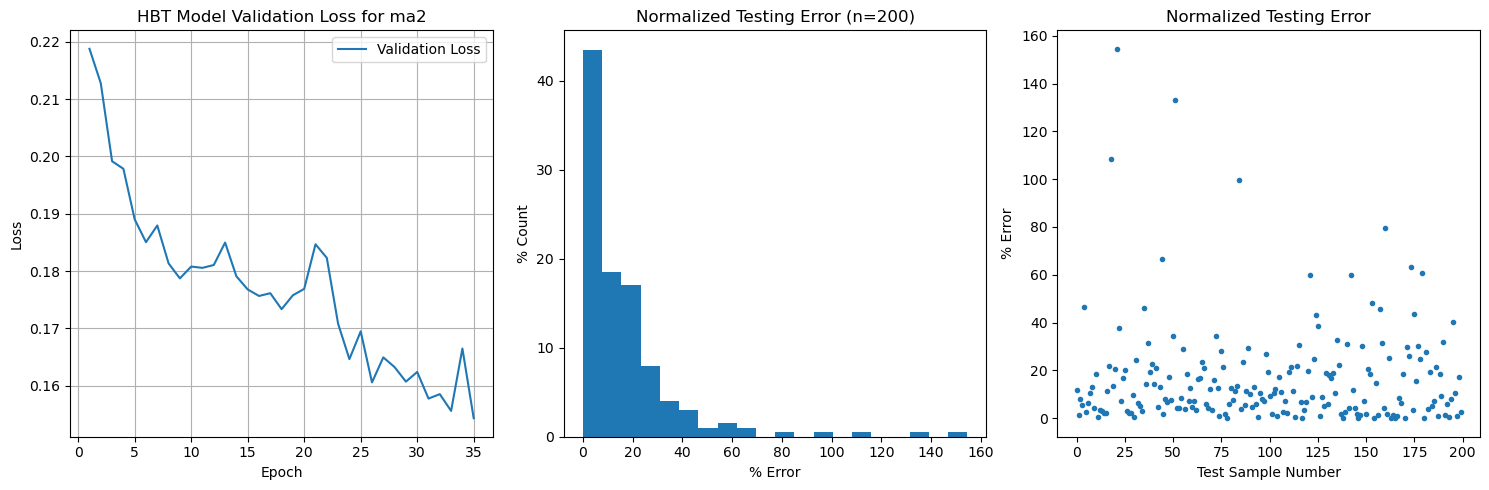

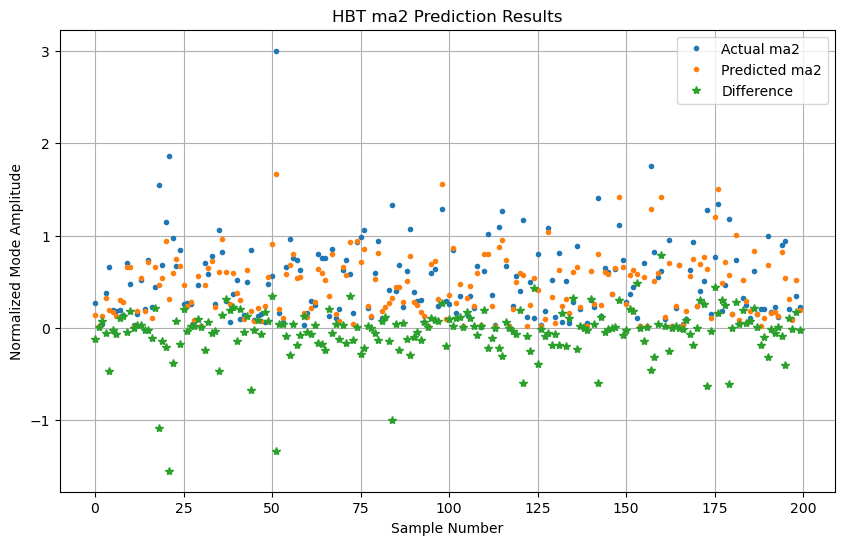

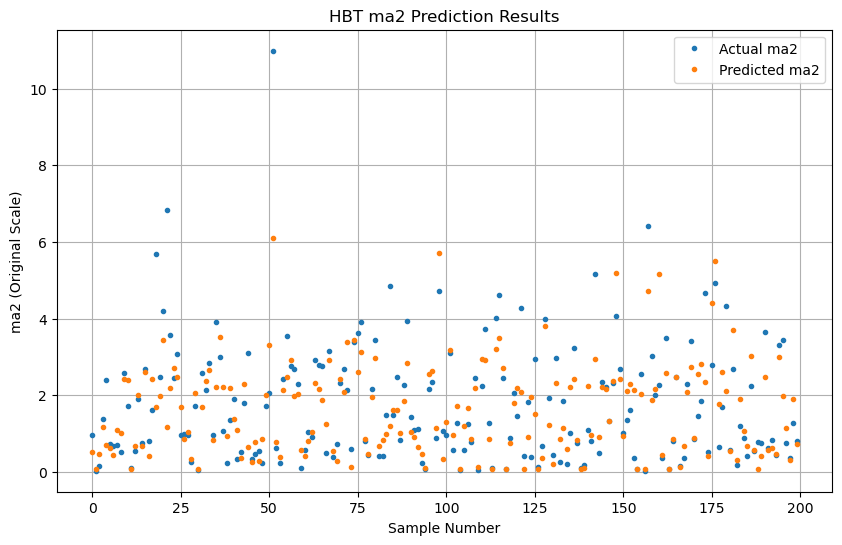

Maximum actual mode amplitude (normalized): 3.00
Maximum predicted mode amplitude (normalized): 1.67
Mean absolute percentage error: 16.49%


In [11]:
# Evaluate the model on test data
predictions = Model.predict(testing_inputs)

# Calculate prediction errors
prediction_errors = np.abs(testing_labels - predictions[:, 0]) * 100

# Create visualization plots
fig, axes = plt.subplots(figsize=(15, 5), ncols=3, nrows=1)

# Plot 1: Training History
axes[0].plot(range(1, len(history.history['val_loss']) + 1), 
             history.history['val_loss'], 
             label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'HBT Model Validation Loss for {selected_data_type}')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Error Distribution
weights = np.ones_like(prediction_errors) / len(prediction_errors) * 100
axes[1].hist(prediction_errors, 20, weights=weights)
axes[1].set_xlabel('% Error')
axes[1].set_ylabel('% Count')
axes[1].set_title('Normalized Testing Error (n=200)')

# Plot 3: Error by Sample
axes[2].plot(prediction_errors, '.')
axes[2].set_xlabel('Test Sample Number')
axes[2].set_ylabel('% Error')
axes[2].set_title('Normalized Testing Error')
plt.tight_layout()
plt.show()

# Plot 4: Actual vs Predicted Values
plt.figure(figsize=(10, 6))
plt.plot(testing_labels, '.', label=f'Actual {selected_data_type}')
plt.plot(predictions[:, 0], '.', label=f'Predicted {selected_data_type}')
plt.plot(-(testing_labels - predictions[:, 0]), '*', label='Difference')
plt.xlabel('Sample Number')
plt.ylabel('Normalized Mode Amplitude')
plt.title(f'HBT {selected_data_type} Prediction Results')
plt.legend()
plt.grid(True)
plt.show()

# Plot original scale predictions
plt.figure(figsize=(10, 6))
plt.plot(testing_labels * ma_norm, '.', label=f'Actual {selected_data_type}')
plt.plot(predictions[:, 0] * ma_norm, '.', label=f'Predicted {selected_data_type}')
plt.xlabel('Sample Number')
plt.ylabel(f'{selected_data_type} (Original Scale)')
plt.title(f'HBT {selected_data_type} Prediction Results')
plt.legend()
plt.grid(True)
plt.show()

print(f"Maximum actual mode amplitude (normalized): {np.max(np.abs(testing_labels)):.2f}")
print(f"Maximum predicted mode amplitude (normalized): {np.max(np.abs(predictions[:, 0])):.2f}")
print(f"Mean absolute percentage error: {np.mean(prediction_errors):.2f}%")

3.6630030918121337
Shot 114458: Camera frames=800, HBT frames=800, Time frames=800
Shape of reserved_shot_cut_2d: (800, 32, 32)
Shape of camera_data: (800, 32, 32)
Input data shape: (800, 32, 32, 1)
Model output shape: (None, 1)


Predictions shape: (800,)


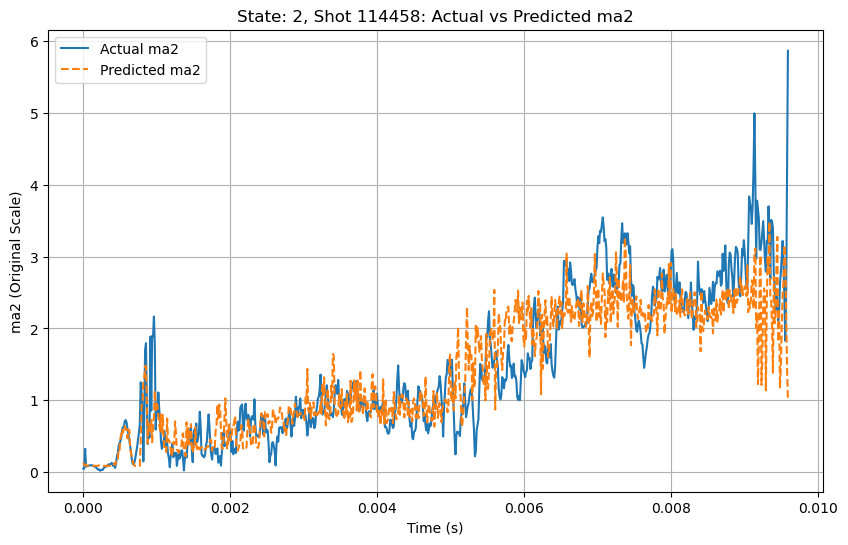

Shot 114458 - Mean absolute percentage error: 9.99%
Shot 114458 - Max actual ma2: 5.87
Shot 114458 - Max predicted ma2: 3.48


In [12]:
print(ma_norm)
def plot_RESERVED_SHOT_predictions(shot, shot_list, cut_training_data_2d, reserved_shot_cut_2d, hbt_dataType, hbt_time_data, model, ma_norm):
    """Plot actual vs predicted Mode 2 amplitude for the reserved shot."""
    if reserved_shot_cut_2d is None:
        print(f"No data available for reserved shot {shot}. No plot generated.")
        return
    
    shot_idx = shot_list.index(shot)
    camera_data = reserved_shot_cut_2d
    hbt_data = hbt_dataType[shot_idx][:, 0]
    time_data = hbt_time_data[shot_idx]

    print(f"Shot {shot}: Camera frames={len(camera_data)}, HBT frames={len(hbt_data)}, Time frames={len(time_data)}")
    print(f"Shape of reserved_shot_cut_2d: {reserved_shot_cut_2d.shape}")
    print(f"Shape of camera_data: {np.array(camera_data).shape}")

    if len(camera_data) == 0:
        print(f"No camera data for shot {shot}. No plot generated.")
        return
    
    if len(camera_data) != len(hbt_data):
        print(f"Warning: Camera data ({len(camera_data)} frames) does not match HBT data ({len(hbt_data)} frames)")

    input_data = np.array(camera_data).reshape(-1, 32, 32, 1)
    print(f"Input data shape: {input_data.shape}")
    print(f"Model output shape: {model.output_shape}")

    predictions = []
    batch_size = 100
    for i in range(0, len(input_data), batch_size):
        batch = input_data[i:i+batch_size]
        batch_pred = model.predict(batch, verbose=0)[:, 0] * ma_norm
        predictions.extend(batch_pred)
    predictions = np.array(predictions)
    print(f"Predictions shape: {predictions.shape}")

    # Rest of the plotting code...
    
    # Plot actual vs predicted using time data
    plt.figure(figsize=(10, 6))
    plt.plot(time_data, hbt_data, label=f'Actual {selected_data_type}')
    plt.plot(time_data, predictions, '--', label=f'Predicted {selected_data_type}')
    plt.xlabel('Time (s)')  # Assuming time is in seconds; adjust if needed
    plt.ylabel(f'{selected_data_type} (Original Scale)')
    plt.title(f'State: {state}, Shot {shot}: Actual vs Predicted {selected_data_type}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print metrics
    prediction_errors = np.abs(hbt_data - predictions) / ma_norm * 100
    print(f"Shot {shot} - Mean absolute percentage error: {np.mean(prediction_errors):.2f}%")
    print(f"Shot {shot} - Max actual {selected_data_type}: {np.max(np.abs(hbt_data)):.2f}")
    print(f"Shot {shot} - Max predicted {selected_data_type}: {np.max(np.abs(predictions)):.2f}")

    return predictions

reserved_predictions = plot_RESERVED_SHOT_predictions(
    RESERVED_SHOT, shot_list, cut_training_data_2D, reserved_shot_cut_2d, hbt_dataType, hbt_time_data, william_model, ma_norm
)

In [13]:
# Save true ma2 data, predictions, and time data for reserved shot
time_data = hbt_time_data[shot_list.index(RESERVED_SHOT)]

print(f"Untrimmed: Saving results for state {state}, shot {RESERVED_SHOT}")
print(f"True data defined: {'hbt_dataType' in locals()}, {'shot_list' in locals()}, {'RESERVED_SHOT' in locals()}")
print(f"Predictions defined: {'predictions' in locals()}, shape: {reserved_predictions.shape if 'predictions' in locals() else 'N/A'}")
print(f"Time data defined: {'hbt_time_data' in locals()}, shape: {hbt_time_data[shot_list.index(RESERVED_SHOT)].shape if 'hbt_time_data' in locals() else 'N/A'}")
np.save(f'results_{notebook_type}_state_{state}_{selected_data_type}_true.npy', hbt_dataType[shot_list.index(RESERVED_SHOT)][:, 0])
np.save(f'results_{notebook_type}_state_{state}_{selected_data_type}_pred.npy', reserved_predictions)
np.save(f'results_{notebook_type}_state_{state}_{selected_data_type}_time.npy', time_data)
print("Done")

Untrimmed: Saving results for state 2, shot 114458
True data defined: True, True, True
Predictions defined: True, shape: (800,)
Time data defined: True, shape: (800,)
Done
